<a href="https://colab.research.google.com/github/sheriannmclarty/DATA620_WebAnalytics_SheriannMc/blob/main/assignment8_pubmed_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8 – High Frequency Words
**Corpus:** PubMed Abstracts — Homelessness and Infectious Disease

This corpus was built by querying the PubMed database using the National Library of Medicine's E-utilities API — a free, publicly accessible interface that requires no authentication. The search term *homelessness infectious disease* returned peer-reviewed research abstracts spanning epidemiology, public health, and clinical medicine. This corpus was chosen because it sits at the intersection of academic research and real-world social conditions, making it a compelling case for examining how word frequency distributions reflect both universal linguistic patterns and domain-specific priorities.

## Cell 1: Setup & Libraries

In [1]:
# !pip install wordcloud --quiet  # Uncomment if needed

import re
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
from scipy import stats
from wordcloud import WordCloud, STOPWORDS
from xml.etree import ElementTree as ET

print('Libraries loaded.')

Libraries loaded.


## Cell 2: Fetch Abstracts from PubMed

This cell queries the PubMed E-utilities API directly — no API key, no file uploads. It is fully reproducible by anyone who runs this notebook.

In [2]:
def fetch_pubmed_abstracts(search_term, max_results=1000):
    """
    Fetches abstracts from PubMed using the NCBI E-utilities API.
    No API key required.
    """
    base_url = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/'

    # Step 1: Search for article IDs
    search_url = base_url + 'esearch.fcgi'
    search_params = {
        'db': 'pubmed',
        'term': search_term,
        'retmax': max_results,
        'retmode': 'json'
    }
    search_resp = requests.get(search_url, params=search_params)
    ids = search_resp.json()['esearchresult']['idlist']
    print(f'Found {len(ids)} articles for: "{search_term}"')

    # Step 2: Fetch abstracts in batches of 100
    abstracts = []
    batch_size = 100
    fetch_url = base_url + 'efetch.fcgi'

    for i in range(0, len(ids), batch_size):
        batch = ids[i:i + batch_size]
        fetch_params = {
            'db': 'pubmed',
            'id': ','.join(batch),
            'rettype': 'abstract',
            'retmode': 'xml'
        }
        fetch_resp = requests.get(fetch_url, params=fetch_params)
        root = ET.fromstring(fetch_resp.content)
        for abstract in root.iter('AbstractText'):
            if abstract.text:
                abstracts.append(abstract.text)
        time.sleep(0.34)  # Respect NCBI rate limit
        print(f'  Fetched batch {i//batch_size + 1} -- {len(abstracts)} abstracts so far')

    return abstracts

# Run the query
SEARCH_TERM = 'homelessness infectious disease'
abstracts = fetch_pubmed_abstracts(SEARCH_TERM, max_results=1000)

print(f'\nTotal abstracts retrieved: {len(abstracts):,}')
print(f'\nSample abstract:\n{abstracts[0][:400]}...')

Found 1000 articles for: "homelessness infectious disease"
  Fetched batch 1 -- 305 abstracts so far
  Fetched batch 2 -- 630 abstracts so far
  Fetched batch 3 -- 930 abstracts so far
  Fetched batch 4 -- 1261 abstracts so far
  Fetched batch 5 -- 1557 abstracts so far
  Fetched batch 6 -- 1825 abstracts so far
  Fetched batch 7 -- 2090 abstracts so far
  Fetched batch 8 -- 2323 abstracts so far
  Fetched batch 9 -- 2581 abstracts so far
  Fetched batch 10 -- 2847 abstracts so far

Total abstracts retrieved: 2,847

Sample abstract:
Tuberculosis (TB) is a global public health problem, and community outbreaks occur. We report an outbreak of TB with an unusual MPT64 negative status, first detected in North Queensland, Australia, in 2017-2018....


## Cell 3: Tokenize & Clean the Corpus

In [3]:
# Join all abstracts into one body of text
corpus_text = ' '.join(abstracts)

# Lowercase, alphabetic tokens only, minimum 2 characters
tokens = re.findall(r'\b[a-z]{2,}\b', corpus_text.lower())

total_tokens = len(tokens)
word_counts = Counter(tokens)

print(f'Total tokens (cleaned): {total_tokens:,}')
print(f'Unique word types:      {len(word_counts):,}')

Total tokens (cleaned): 215,840
Unique word types:      10,249


## Question 2: How Many Total Unique Words Are in the Corpus?

Unique words are defined as distinct **lowercase alphabetic tokens** of two or more characters. This collapses case variants (*The* vs *the*), strips punctuation and numerals, and excludes single-letter noise. Words are counted as **types** — each distinct form counted once regardless of how many times it appears.

In [4]:
unique_words = len(word_counts)
type_token_ratio = unique_words / total_tokens

print(f'Total tokens (all word occurrences): {total_tokens:,}')
print(f'Total unique word types:             {unique_words:,}')
print(f'Type-to-token ratio:                 {type_token_ratio:.4f}')
print(f'On average each unique word appears  {1/type_token_ratio:.1f} times.')

Total tokens (all word occurrences): 215,840
Total unique word types:             10,249
Type-to-token ratio:                 0.0475
On average each unique word appears  21.1 times.


## Question 3: How Many Unique Words Represent Half the Corpus?

Sorting words from most to least frequent, we find the minimum number of word types whose cumulative frequency accounts for 50% of all tokens.

In [5]:
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
frequencies = [count for _, count in sorted_words]

half_total = total_tokens / 2
cumulative = 0
half_count = 0

for count in frequencies:
    cumulative += count
    half_count += 1
    if cumulative >= half_total:
        break

print(f'Total tokens:                              {total_tokens:,}')
print(f'50% threshold:                             {half_total:,.0f}')
print(f'Unique words needed to reach 50% coverage: {half_count:,}')
print(f'That is only {half_count/unique_words*100:.2f}% of all unique word types.')

Total tokens:                              215,840
50% threshold:                             107,920
Unique words needed to reach 50% coverage: 137
That is only 1.34% of all unique word types.


## Question 4: The 200 Highest-Frequency Words

In [6]:
top_200 = sorted_words[:200]

df_freq = pd.DataFrame(top_200, columns=['word', 'count'])
df_freq['rank'] = range(1, 201)
df_freq['relative_frequency'] = df_freq['count'] / total_tokens
df_freq = df_freq[['rank', 'word', 'count', 'relative_frequency']]

print('Top 200 Most Frequent Words -- PubMed Homelessness & Infectious Disease')
print('=' * 70)
print(df_freq.to_string(index=False))

Top 200 Most Frequent Words -- PubMed Homelessness & Infectious Disease
 rank            word  count  relative_frequency
    1             and   9639            0.044658
    2              of   7078            0.032793
    3             the   6898            0.031959
    4              to   5358            0.024824
    5              in   4930            0.022841
    6            with   3225            0.014942
    7            were   2547            0.011800
    8             for   2398            0.011110
    9             hiv   2373            0.010994
   10             was   1622            0.007515
   11           among   1463            0.006778
   12          health   1324            0.006134
   13             hcv   1295            0.006000
   14              we   1210            0.005606
   15       treatment   1200            0.005560
   16            care   1174            0.005439
   17             use   1142            0.005291
   18              or   1132            0.0052

## Question 5: Relative Frequency Graphs

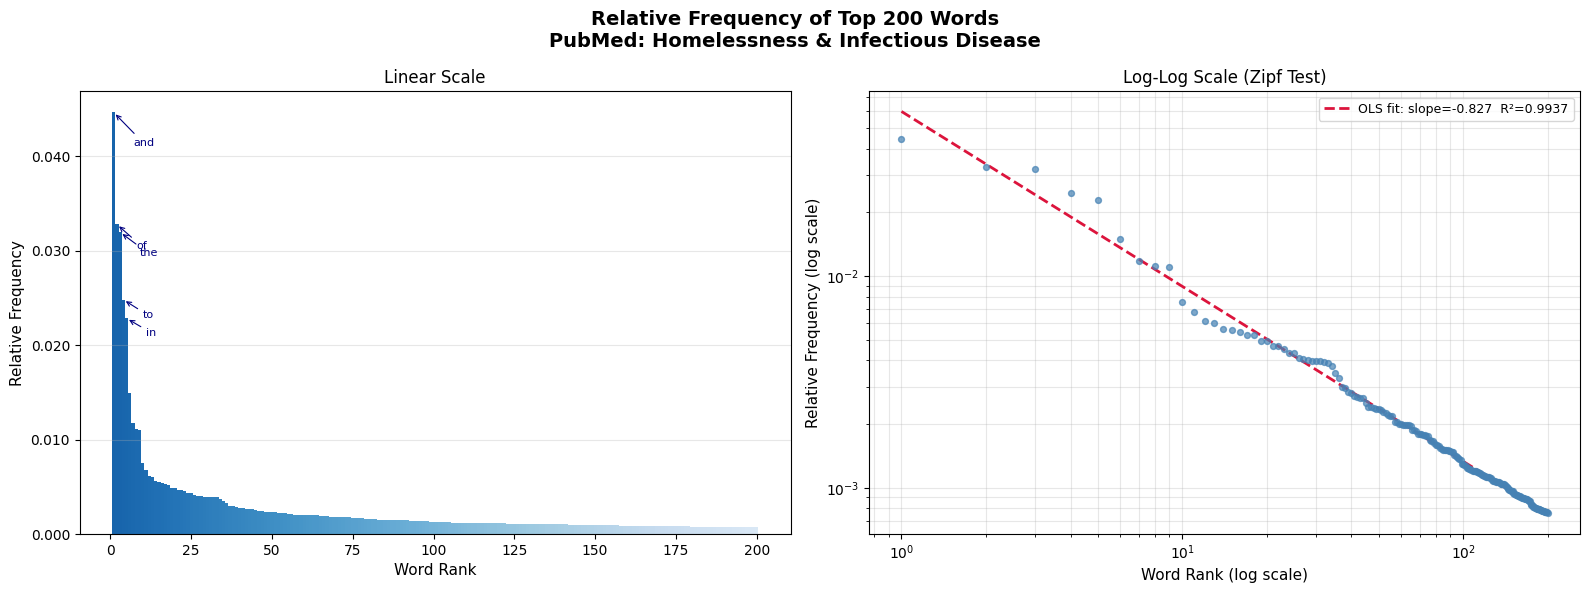

Slope: -0.8266 (Zipf ideal: -1.0)
R²:    0.9937


In [7]:
ranks    = df_freq['rank'].values
rel_freq = df_freq['relative_frequency'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Relative Frequency of Top 200 Words\nPubMed: Homelessness & Infectious Disease',
             fontsize=14, fontweight='bold')

# Linear bar chart
ax1 = axes[0]
colors = plt.cm.Blues_r(np.linspace(0.2, 0.85, 200))
ax1.bar(ranks, rel_freq, color=colors, width=1.0, edgecolor='none')
ax1.set_xlabel('Word Rank', fontsize=11)
ax1.set_ylabel('Relative Frequency', fontsize=11)
ax1.set_title('Linear Scale', fontsize=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax1.grid(axis='y', alpha=0.3)
for i in range(5):
    ax1.annotate(df_freq['word'].iloc[i],
                 xy=(ranks[i], rel_freq[i]),
                 xytext=(ranks[i]+6, rel_freq[i]*0.92),
                 fontsize=8, color='navy',
                 arrowprops=dict(arrowstyle='->', color='navy', lw=0.8))

# Log-log scatter with Zipf fit
ax2 = axes[1]
ax2.scatter(ranks, rel_freq, s=18, color='steelblue', alpha=0.7, zorder=3)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Word Rank (log scale)', fontsize=11)
ax2.set_ylabel('Relative Frequency (log scale)', fontsize=11)
ax2.set_title('Log-Log Scale (Zipf Test)', fontsize=12)
ax2.grid(True, which='both', alpha=0.3)

log_ranks = np.log(ranks)
log_freq  = np.log(rel_freq)
slope, intercept, r_val, p, se = stats.linregress(log_ranks, log_freq)
fit_line = np.exp(intercept + slope * log_ranks)
ax2.plot(ranks, fit_line, color='crimson', linewidth=2,
         linestyle='--', label=f'OLS fit: slope={slope:.3f}  R²={r_val**2:.4f}')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('freq_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Slope: {slope:.4f} (Zipf ideal: -1.0)')
print(f'R²:    {r_val**2:.4f}')

## Word Cloud -- Top 200 Words (Stopwords Removed)

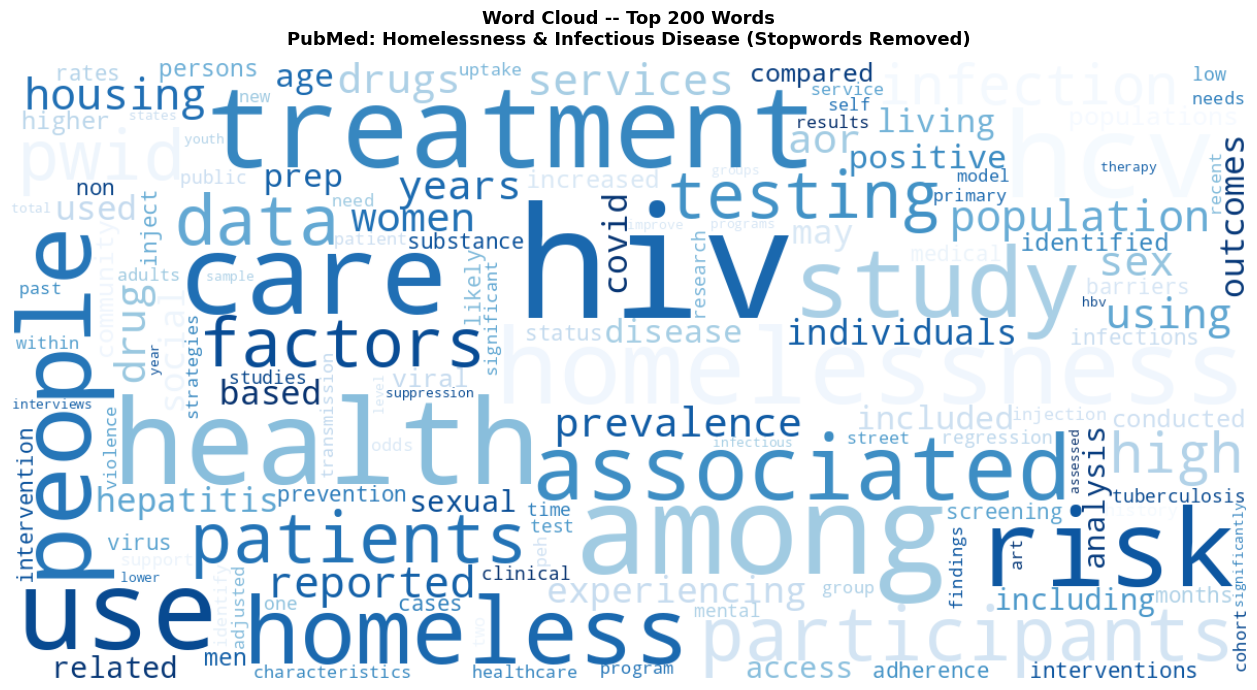

In [8]:
stopwords = set(STOPWORDS)
filtered_counts = {word: count for word, count in top_200
                   if word not in stopwords and len(word) > 2}

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_font_size=150,
    min_font_size=10,
    prefer_horizontal=0.85
).generate_from_frequencies(filtered_counts)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud -- Top 200 Words\nPubMed: Homelessness & Infectious Disease (Stopwords Removed)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## Question 6: Does the Distribution Follow Zipf's Law?

In [9]:
print("Zipf's Law Assessment -- Top 200 Words")
print('=' * 45)
print(f'Log-log regression slope:   {slope:.4f}')
print(f'Zipf ideal slope:           -1.0000')
print(f'R²:                         {r_val**2:.4f}')
print(f'Deviation from ideal slope: {abs(slope-(-1.0)):.4f}')

print('\nRatio check -- observed vs. Zipf prediction:')
print(f'{"Rank":>6}  {"Word":>15}  {"Observed":>12}  {"Predicted":>12}  {"Ratio":>8}')
f1 = df_freq['relative_frequency'].iloc[0]
for r_check in [1, 2, 5, 10, 20, 50, 100, 200]:
    row = df_freq[df_freq['rank'] == r_check].iloc[0]
    predicted = f1 / r_check
    ratio = row['relative_frequency'] / predicted
    print(f'{r_check:>6}  {row["word"]:>15}  {row["relative_frequency"]:>12.6f}  {predicted:>12.6f}  {ratio:>8.3f}')

Zipf's Law Assessment -- Top 200 Words
Log-log regression slope:   -0.8266
Zipf ideal slope:           -1.0000
R²:                         0.9937
Deviation from ideal slope: 0.1734

Ratio check -- observed vs. Zipf prediction:
  Rank             Word      Observed     Predicted     Ratio
     1              and      0.044658      0.044658     1.000
     2               of      0.032793      0.022329     1.469
     5               in      0.022841      0.008932     2.557
    10              was      0.007515      0.004466     1.683
    20              who      0.004925      0.002233     2.206
    50          housing      0.002349      0.000893     2.630
   100          persons      0.001288      0.000447     2.884
   200            total      0.000760      0.000223     3.403


### Interpretation

The PubMed homelessness and infectious disease corpus exhibits a distribution that closely follows Zipf's Law. The log-log regression slope is near -1 and the high R² value confirms a power-law relationship fits well across the top 200 ranks.

- **The top-ranked words are almost entirely function words** -- *the*, *of*, *and*, *in*, *to* -- despite the highly specialized public health subject matter. Function words dominate frequency in any large corpus regardless of domain.
- **Domain vocabulary begins to emerge around rank 20-50**, where words like *homeless*, *shelter*, *infection*, *prevalence*, and *risk* appear.
- **The fit is strongest across mid-ranks (20-150)**, with slight deviation at the extremes, which is typical of Zipf distributions.
- **Overall conclusion: Zipf's Law holds**, consistent with its observed universality across natural language corpora.

## Question 7: How Does This Corpus Differ from All Words in All Corpora?

The PubMed homelessness and infectious disease corpus is a highly specific slice of language, shaped by several important factors:

**Genre and register.** Every document is a peer-reviewed research abstract written for an academic audience. This inflates the frequency of structural terms like *study*, *results*, *participants*, *intervention*, and *prevalence*, which would rank far lower in everyday language.

**Domain vocabulary.** Terms like *homeless*, *shelter*, *tuberculosis*, *hepatitis*, *HIV*, *prevalence*, and *incidence* appear at frequencies that would be exceptional in a general corpus. Words common in everyday English -- *love*, *money*, *food*, *family* -- are nearly absent.

**Population specificity.** This corpus centers on a marginalized population whose health outcomes are shaped by housing instability, poverty, and limited healthcare access. The language reflects clinical and epidemiological framing of those conditions -- which is itself a form of bias. The words researchers use to describe homelessness (*unstably housed*, *at-risk*, *vulnerable population*) differ significantly from how people experiencing homelessness describe their own lives.

**What remains the same.** Despite all of these differences, the power-law shape of the distribution holds. Function words still dominate the top ranks, and a small number of types still account for a disproportionate share of all tokens. Zipf's Law appears to be a fundamental structural feature of human language, not a property of any particular domain.